In [2]:
# Linear regression with Transformer encoder

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import time


In [3]:
# --- 1. Generate Data ---

# Set seed for reproducibility
torch.manual_seed(42)

# --- 1. Generate synthetic data ---
input_dim = 4
n_samples = 1000
batch_size = 100

true_w = torch.randn(input_dim)
true_b = 0.5

X = torch.randn(n_samples, input_dim)
y = X @ true_w + true_b + 0.1 * torch.randn(n_samples)  # Linear function + noise

# Train/test split
train_n = int(round(0.8 * n_samples, 0))
train_X, test_X = X[:train_n], X[train_n:]
train_y, test_y = y[:train_n], y[train_n:]

train_loader = DataLoader(TensorDataset(train_X, train_y), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(test_X, test_y), batch_size=batch_size)


In [18]:
train_X[0], train_y[0]

(tensor([ 1.7878, -0.4780, -0.2429, -0.9342]), tensor(0.7541))

In [6]:
#--- 1. Linear baseline
class LinearRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x).squeeze(-1)


In [8]:
# --- 2. Transformer Model for Regression ---
class TransformerForLinearRegression(nn.Module):
    def __init__(self, input_dim, d_model=16, nhead=2, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output = nn.Linear(d_model, 1)
        # self.output = nn.Sequential(
        #     nn.Linear(d_model, 8),
        #     nn.ReLU(),                  # Non-linearity
        #     nn.Linear(8, 1)    # Output layer
        # )
        
    def forward(self, x):
        # x: (batch_size, input_dim)
        x = x.unsqueeze(-1)  # (batch_size, input_dim, 1)
        x = self.embedding(x)  # (batch_size, input_dim, d_model)
        x = x.permute(1, 0, 2)  # (seq_len, batch_size, d_model)
        x = self.transformer(x)  # (seq_len, batch_size, d_model)
        x = x.mean(dim=0)  # Mean pooling: (batch_size, d_model)
        return self.output(x).squeeze(-1)  # (batch_size,)

Let’s write out the **explicit equation for $\hat{y}$** (the prediction from input $x$) for your transformer regression model, step by step, **including the attention layer**.

---

## 🔢 Notation

Let’s define:

* Input sample $x = [x_1, x_2, x_3, x_4] \in \mathbb{R}^4$
* Batch size = 1 (for clarity)
* $d_{\text{model}}$ = hidden dimension (e.g., 16)
* $W_{\text{emb}} \in \mathbb{R}^{d_{\text{model}} \times 1}$, $b_{\text{emb}} \in \mathbb{R}^{d_{\text{model}}}$ – weights of embedding layer
* $\mathbf{z}_i = W_{\text{emb}} x_i + b_{\text{emb}} \in \mathbb{R}^{d_{\text{model}}}$ – embedded token

---

## Step 1: **Embedding Each Scalar Feature**

For each $x_i$, the embedding is:

$$
\mathbf{z}_i = W_{\text{emb}} x_i + b_{\text{emb}} \quad \text{for } i = 1,2,3,4
$$

You now have 4 embedded tokens $\mathbf{z}_1, \mathbf{z}_2, \mathbf{z}_3, \mathbf{z}_4$.

---

## Step 2: **Self-Attention Layer (Simplified for 1 Layer)**

### Attention mechanism for one head:

1. Compute **queries, keys, values**:

$$
Q_i = W_Q \mathbf{z}_i, \quad K_i = W_K \mathbf{z}_i, \quad V_i = W_V \mathbf{z}_i
$$

with $W_Q, W_K, W_V \in \mathbb{R}^{d_k \times d_{\text{model}}}$.

2. Attention scores for token $i$:

$$
\alpha_{ij} = \frac{\exp(Q_i^\top K_j / \sqrt{d_k})}{\sum_{j'=1}^{4} \exp(Q_i^\top K_{j'} / \sqrt{d_k})}
$$

3. Attention output for token $i$:

$$
\tilde{z}_i = \sum_{j=1}^{4} \alpha_{ij} V_j
$$

### After self-attention:

You have new token representations $\tilde{z}_1, \tilde{z}_2, \tilde{z}_3, \tilde{z}_4$.

(If multi-head, you'd concatenate results from each head and linearly project.)

---

## Step 3: **Mean Pooling**

You average over the 4 tokens:

$$
\bar{z} = \frac{1}{4} \sum_{i=1}^4 \tilde{z}_i \in \mathbb{R}^{d_{\text{model}}}
$$

---

## Step 4: **Final Linear Output Layer**

Let $W_{\text{out}} \in \mathbb{R}^{1 \times d_{\text{model}}}, b_{\text{out}} \in \mathbb{R}$

Compute:

$$
\hat{y} = W_{\text{out}} \bar{z} + b_{\text{out}} \in \mathbb{R}
$$

---

## 🔄 Full Equation Summary (Chained)

$$
\hat{y} = W_{\text{out}} \left( \frac{1}{4} \sum_{i=1}^4 \text{Attention}\left(\mathbf{z}_1,\ldots,\mathbf{z}_4\right)_i \right) + b_{\text{out}}
$$

Where each $\mathbf{z}_i = W_{\text{emb}} x_i + b_{\text{emb}}$, and attention aggregates them **based on learned weights** (not just average).

---

## 🧠 Key Insight

* The transformer **learns to weight and mix features $x_i$** through **attention**.
* Unlike simple averaging, it **adapts the weighting based on the feature content**.

---

Let me know if you'd like the **matrix form** for batching or multi-head version.


In [10]:
# instead of taking mean of the contextual embeddings of x1 x2 x3 x4, we concatenate them all 
# and add a non-linear MLP at the end to handle non-linearity
class TransformerWithFlattenMLP(nn.Module):
    def __init__(self, input_dim, d_model=16, nhead=1, num_layers=1, mlp_hidden=8):
        super().__init__()
        self.input_dim = input_dim
        self.d_model = d_model

        self.embedding = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Fix in_features to input_dim * d_model
        self.mlp = nn.Sequential(
            nn.Linear(input_dim * d_model, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, 1)
        )
    
    def forward(self, x):
        x = x.unsqueeze(-1)           # (batch_size, input_dim, 1)
        x = self.embedding(x)         # (batch_size, input_dim, d_model)
        x = x.permute(1, 0, 2)        # (seq_len, batch_size, d_model)
        x = self.transformer(x)       # (seq_len, batch_size, d_model)
        x = x.permute(1, 0, 2)        # (batch_size, seq_len, d_model)
        x = x.reshape(x.size(0), -1)  # (batch_size, input_dim * d_model)
        return self.mlp(x).squeeze(-1)


In [12]:
# --- 3. MLP multilayer perceptron ---

class MLPRegression(nn.Module):
    def __init__(self, input_dim, hidden_dim = 16):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(-1)


# class MLPRegression(nn.Module):
#     def __init__(self, input_dim, hidden_dim=64, num_layers=2):
#         super().__init__()
#         layers = []
#         dims = [input_dim] + [hidden_dim] * (num_layers - 1)
        
#         # Add hidden layers with ReLU activation
#         for in_dim, out_dim in zip(dims[:-1], dims[1:]):
#             layers.append(nn.Linear(in_dim, out_dim))
#             layers.append(nn.ReLU())
        
#         # Final output layer (no activation)
#         layers.append(nn.Linear(hidden_dim, 1))
#         self.model = nn.Sequential(*layers)

#     def forward(self, x):
#         return self.model(x).squeeze(-1)


In [14]:
# --- 4. SVM ---

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

def train_svr(train_X, train_y, test_X, test_y): 
    # --- Convert to numpy for sklearn ---
    train_X_np = train_X.numpy()
    train_y_np = train_y.numpy()
    test_X_np = test_X.numpy()
    test_y_np = test_y.numpy()

    # --- Standardize features ---
    scaler = StandardScaler()
    train_X_np = scaler.fit_transform(train_X_np)
    test_X_np = scaler.transform(test_X_np)

    # ---  Train SVR with different kernels ---
    kernels = ['linear', 'rbf', 'poly']
    svr1 = SVR(kernel=kernels[0], C=1.0, epsilon=0.1)
    svr1.fit(train_X_np, train_y_np)

    svr2 = SVR(kernel=kernels[1], C=1.0, epsilon=0.1)
    svr2.fit(train_X_np, train_y_np)

    svr3 = SVR(kernel=kernels[2], C=1.0, epsilon=0.1)
    svr3.fit(train_X_np, train_y_np)

    # Predict and evaluate
    mse1 = mean_squared_error(test_y_np, svr1.predict(test_X_np))
    mse2 = mean_squared_error(test_y_np, svr2.predict(test_X_np))
    mse3 = mean_squared_error(test_y_np, svr3.predict(test_X_np))
    print(f"Kernel: {kernels[0]} | Test MSE: {mse1:.4f}")
    print(f"Kernel: {kernels[1]} | Test MSE: {mse2:.4f}")
    print(f"Kernel: {kernels[2]} | Test MSE: {mse3:.4f}")
    
    return svr1, svr2, svr3

Comment: 
* nn.TransformerEncoderLayer(...): defines a single block of multi-head attention + feed-forward + normalization.
* nn.TransformerEncoder(...): stacks multiple such layers (num_layers times).
* Both are needed if you want multiple encoder layers

Training Transformer...


C:\Users\dinab\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch 1/100 | Loss: 456.4676
Epoch 11/100 | Loss: 30.9211
Epoch 21/100 | Loss: 29.0516
Epoch 31/100 | Loss: 29.2593
Epoch 41/100 | Loss: 28.0247
Epoch 51/100 | Loss: 27.6456
Epoch 61/100 | Loss: 28.6416
Epoch 71/100 | Loss: 28.4475
Epoch 81/100 | Loss: 27.1012
Epoch 91/100 | Loss: 27.8277


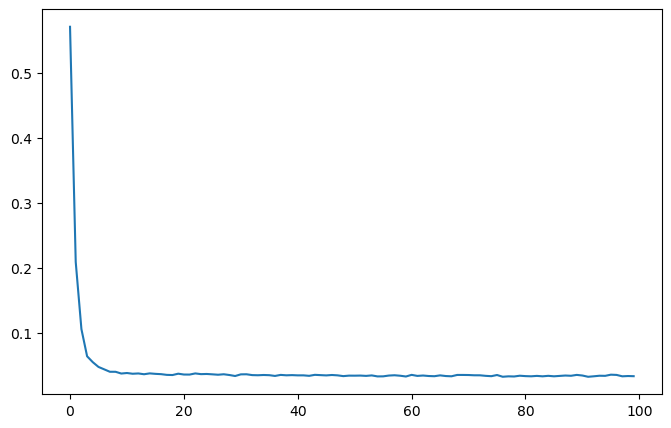

In [14]:
# --- 4. Run Training ---
print("Training Transformer...")
transformer_model = TransformerForLinearRegression(input_dim=input_dim)
transformer_losses, transformer_mse, transformer_preds, transformer_targets, transformer_time = train_model(transformer_model, train_loader, test_loader,n_epochs = 100)

plt.figure(figsize=(8, 5))
plt.plot(transformer_losses, label="Transformer")
plt.show()

In [12]:
# --- 3. Train Function ---
def train_model(model, train_loader, test_loader, n_epochs=30, lr = 1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses = []

    start = time.time()
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        train_losses.append(total_loss / len(train_loader.dataset))
        if (epoch%10 == 0): print(f"Epoch {epoch+1}/{n_epochs} | Loss: {total_loss:.4f}")
    end = time.time()

    # Evaluate
    model.eval()
    with torch.no_grad():
        preds, targets = [], []
        for xb, yb in test_loader:
            pred = model(xb)
            preds.append(pred)
            targets.append(yb)
        preds = torch.cat(preds)
        targets = torch.cat(targets)
        test_mse = F.mse_loss(preds, targets).item()

    return train_losses, test_mse, preds, targets, end - start


Training Linear Regression...
Epoch 1/100 | Loss: 416.5270
Epoch 11/100 | Loss: 8.0280
Epoch 21/100 | Loss: 7.5930
Epoch 31/100 | Loss: 7.6027
Epoch 41/100 | Loss: 7.6366
Epoch 51/100 | Loss: 7.6279
Epoch 61/100 | Loss: 7.6117
Epoch 71/100 | Loss: 7.6810
Epoch 81/100 | Loss: 7.6317
Epoch 91/100 | Loss: 7.6401

Transformer Test MSE: 0.0267, Time: 22.71s
Linear     Test MSE: 0.0110, Time: 1.06s


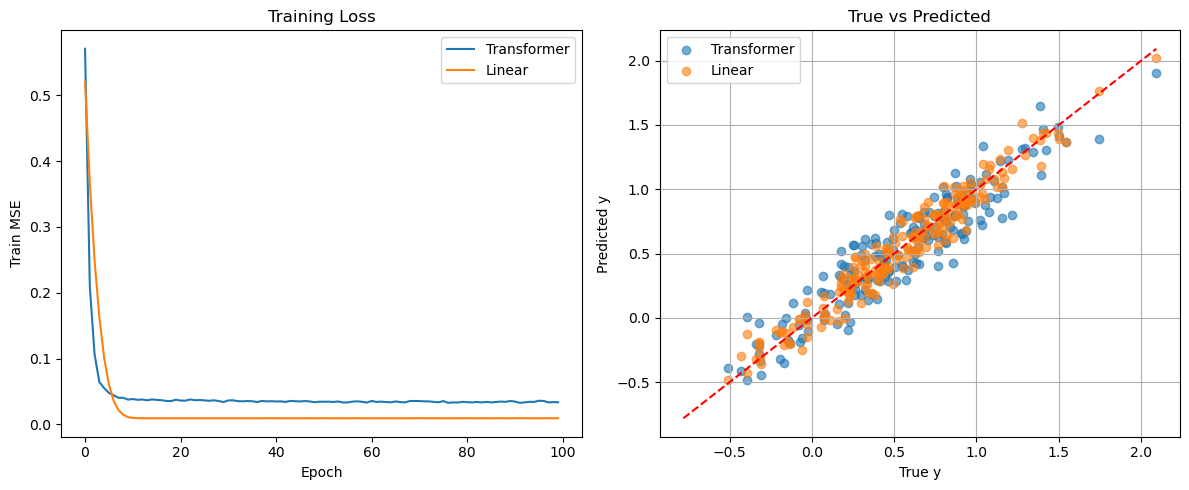

In [16]:
print("\nTraining Linear Regression...")
linear_model = LinearRegression(input_dim=input_dim)
linear_losses, linear_mse, linear_preds, linear_targets, linear_time = train_model(linear_model, train_loader, test_loader, n_epochs = 100, lr = 1e-2)

# --- 5. Print and Plot Results ---
print(f"\nTransformer Test MSE: {transformer_mse:.4f}, Time: {transformer_time:.2f}s")
print(f"Linear     Test MSE: {linear_mse:.4f}, Time: {linear_time:.2f}s")

# Plot losses
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(transformer_losses, label="Transformer")
plt.plot(linear_losses, label="Linear")
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("Training Loss")
plt.legend()

# Plot predictions
plt.subplot(1, 2, 2)
plt.scatter(transformer_targets.numpy(), transformer_preds.numpy(), label="Transformer", alpha=0.6)
plt.scatter(linear_targets.numpy(), linear_preds.numpy(), label="Linear", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("True vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2 Trying with non-linear sin() predictions 

🔁 Changes from Linear Case
Change the target from y = wᵀx + b + noise to y = sin(wᵀx) + noise

Keep everything else: same models, same training loop, same evaluation



In [395]:
# --- 1. Synthetic Nonlinear Data: y = sin(wᵀx) + ε ---
input_dim = 4
n_samples = 10000
true_w = torch.randn(input_dim)

X = torch.randn(n_samples, input_dim)
y = torch.sin(X @ true_w) + 0.1 * torch.randn(n_samples)  # non-linear + noise

train_n = int(round(0.8 * n_samples, 0))
# Split
train_X, test_X = X[:train_n], X[train_n:]
train_y, test_y = y[:train_n], y[train_n:]

train_loader = DataLoader(TensorDataset(train_X, train_y), batch_size=500, shuffle=True)
test_loader = DataLoader(TensorDataset(test_X, test_y), batch_size=500)

In [397]:
transformer_model = TransformerForLinearRegression(input_dim=input_dim)

C:\Users\dinab\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [399]:
# --- 4. Run Training ---
print("Training Transformer...")
transformer_losses, transformer_mse, transformer_preds, transformer_targets, transformer_time = train_model(transformer_model, train_loader, test_loader,n_epochs = 50, lr = 1e-2)
#plt.figure(figsize=(3, 2))
#plt.plot(transformer_losses, label="Transformer")
#plt.show()

Training Transformer...
Epoch 1/50 | Loss: 5561.0055
Epoch 11/50 | Loss: 3587.6270
Epoch 21/50 | Loss: 3575.4927
Epoch 31/50 | Loss: 3559.2047
Epoch 41/50 | Loss: 3534.4326


In [400]:
print("Training MLP") 
mlp_model = MLPRegression(input_dim = input_dim)
mlp_losses, mlp_mse, mlp_preds, mlp_targets, mlp_time = train_model(mlp_model, train_loader, test_loader,n_epochs = 50, lr = 1e-2)

Training MLP
Epoch 1/50 | Loss: 3034.0273
Epoch 11/50 | Loss: 90.1322
Epoch 21/50 | Loss: 88.5136
Epoch 31/50 | Loss: 87.7746
Epoch 41/50 | Loss: 87.5183


In [401]:
print("\nTraining Linear Regression...")
linear_model = LinearRegression(input_dim=input_dim)
linear_losses, linear_mse, linear_preds, linear_targets, linear_time = train_model(linear_model, train_loader,test_loader, n_epochs = 50, lr = 1e-2)



Training Linear Regression...
Epoch 1/50 | Loss: 2771.3358
Epoch 11/50 | Loss: 2286.9099
Epoch 21/50 | Loss: 2286.6865
Epoch 31/50 | Loss: 2289.2084
Epoch 41/50 | Loss: 2288.7619


In [402]:
print("\nTraining SVR...")
svr1, svr2, svr3 = train_svr(train_X,train_y,test_X, test_y)


Training SVR...
Kernel: linear | Test MSE: 0.3498
Kernel: rbf | Test MSE: 0.0117
Kernel: poly | Test MSE: 0.4163


In [403]:
print("\nTraining Transformer enhanced with flattened MLP Regression...")
tr_model2 = TransformerWithFlattenMLP(input_dim=input_dim)
t2_losses, t2_mse, t2_preds, t2_targets, t2_time = train_model(tr_model2, train_loader,test_loader, n_epochs = 50, lr = 1e-2)




Training Transformer enhanced with flattened MLP Regression...


C:\Users\dinab\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch 1/50 | Loss: 2084.5776
Epoch 11/50 | Loss: 380.9804
Epoch 21/50 | Loss: 250.0509
Epoch 31/50 | Loss: 209.9710
Epoch 41/50 | Loss: 189.7464



Transformer Test MSE: 0.4471, Time: 83.91s
Linear     Test MSE: 0.2687, Time: 3.15s
MLP     Test MSE: 0.0110, Time: 3.57s


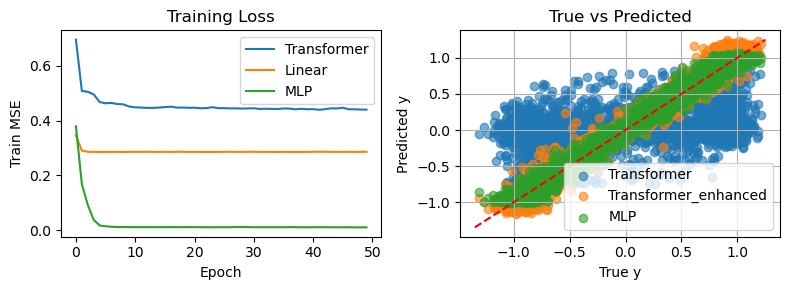

In [404]:
# --- 5. Print and Plot Results ---
print(f"\nTransformer Test MSE: {transformer_mse:.4f}, Time: {transformer_time:.2f}s")
print(f"Linear     Test MSE: {linear_mse:.4f}, Time: {linear_time:.2f}s")
print(f"MLP     Test MSE: {mlp_mse:.4f}, Time: {mlp_time:.2f}s")
# Plot losses
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(transformer_losses, label="Transformer")
plt.plot(linear_losses, label="Linear")
plt.plot(mlp_losses, label="MLP")
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("Training Loss")
plt.legend()

# Plot predictions
plt.subplot(1, 2, 2)
plt.scatter(transformer_targets.numpy(), transformer_preds.numpy(), label="Transformer", alpha=0.6)
plt.scatter(t2_targets.numpy(), t2_preds.numpy(), label="Transformer_enhanced", alpha=0.6)
plt.scatter(mlp_targets.numpy(), mlp_preds.numpy(), label="MLP", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("True vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Actual vs Model Predictions, x_dim = 4, n=10000')

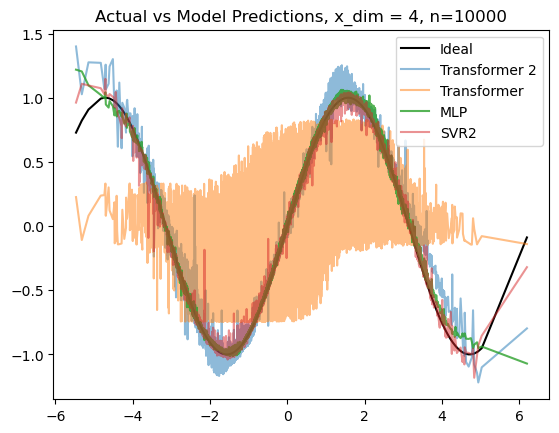

In [405]:
#--- Plot predicted y and actual to see sinus and how close the predictions are
#--- for that, compute X*true_w, then sort it, then plot sin(X*true) and actual and predicted ys 

x_comb = np.matmul(X,true_w)
x_comb_sort = x_comb.sort().values
y_comb_index = x_comb.sort().indices

#plt.plot(x_comb_sort, np.sin(x_comb_sort))
#plt.scatter(x_comb_sort, y[y_comb_index])

linear_model.eval()
transformer_model.eval()
mlp_model.eval()
tp2 = tr_model2(X)
lp = linear_model(X)
tp = transformer_model(X)
mlpp = mlp_model(X)
svr1p = svr1.predict(X)
svr2p = svr2.predict(X)
svr3p = svr3.predict(X)

plt.plot(x_comb_sort, np.sin(x_comb_sort), label = "Ideal", color = "black")
plt.plot(x_comb_sort,tp2.detach().cpu().numpy()[y_comb_index], label = "Transformer 2", alpha = 0.5)
plt.plot(x_comb_sort,tp.detach().cpu().numpy()[y_comb_index], label = "Transformer", alpha = 0.5)
plt.plot(x_comb_sort,mlpp.detach().cpu().numpy()[y_comb_index], label = "MLP", alpha = 0.8)
plt.plot(x_comb_sort,svr2p[y_comb_index], label = "SVR2", alpha = 0.5)
plt.legend()
plt.title(f"Actual vs Model Predictions, x_dim = 4, n={n_samples}")

In [417]:

mses = [n_samples,
        mean_squared_error(y[train_n:],tp2.detach().cpu().numpy()[train_n:]),
        mean_squared_error(y[train_n:],tp.detach().cpu().numpy()[train_n:]),
        mean_squared_error(y[train_n:],mlpp.detach().cpu().numpy()[train_n:]),
        mean_squared_error(y[train_n:],svr1p[train_n:]),
        mean_squared_error(y[train_n:],svr2p[train_n:]),
        mean_squared_error(y[train_n:],svr3p[train_n:])]
mses


[10000,
 0.01822386,
 0.4470887,
 0.010965919,
 0.34890366656404476,
 0.011752875784488937,
 0.4144806512065605]

Text(0.5, 1.0, 'SVR Predictions')

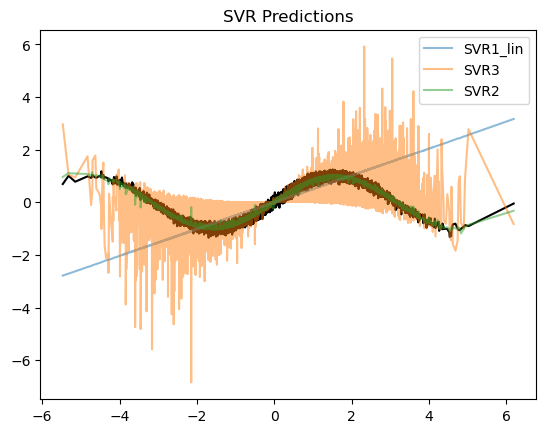

In [419]:
plt.plot(x_comb_sort, y[y_comb_index], color = "black")
plt.plot(x_comb_sort,svr1p[y_comb_index], alpha = 0.5, label = "SVR1_lin")
plt.plot(x_comb_sort,svr3p[y_comb_index], alpha = 0.5, label = "SVR3")
plt.plot(x_comb_sort,svr2p[y_comb_index], alpha = 0.5, label = "SVR2")
plt.legend()
plt.title("SVR Predictions")